# Regression Stats Practice - Maximal Features

For gaining familiarity with using Python for regression problems instead of relying on R. Using traditional statistics techniques.

## SETUP

In [1]:
import pathlib
import json
import typing as T
import warnings

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sklearn.impute as skimp
import sklearn.preprocessing as skprep
import sklearn.metrics as skmetrics
import sklearn.model_selection as skm

import statsmodels.api as sm

In [2]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

## DATA COLLECTION

In [3]:
ds = datasets.load_dataset("michaelmallari/house-prices-advanced-regression-techniques")
src_df = ds["train"].to_pandas()

In [4]:
with open(pathlib.Path(".", "selected-features.json"), "r") as f:
    selected_features = json.load(f)

In [5]:
dependent_var = "SalePrice"

## DATA PREPROCESSING

In [6]:
def engineer_features(
    src_df: pd.DataFrame | T.Iterator[pd.DataFrame],
    selected_features: list[str],
) -> pd.DataFrame:
    encodable_cols = src_df.select_dtypes(["object", "str"]).nunique(dropna=True).index

    df = (
        skimp.SimpleImputer(missing_values=pd.NA, strategy="most_frequent")
        .set_output(transform="pandas")
        .fit_transform(src_df)
    )
    df = pd.get_dummies(df, columns=encodable_cols, drop_first=True, dtype="float64")
    df = df.loc[:, selected_features]

    for col in df.columns:  # quadratic transformation
        if col != dependent_var:
            df.loc[:, f"{col}_sq"] = np.square(df[col].astype("float64"))

    df = skprep.StandardScaler().set_output(transform="pandas").fit_transform(df)
    df = sm.add_constant(df)
    df.loc[:, dependent_var] = src_df[dependent_var]

    return df

In [7]:
prep_df = engineer_features(src_df, selected_features)

In [8]:
train_df, test_df = skm.train_test_split(prep_df, test_size=0.2)

## REGRESSION

In [9]:
def plot_homoscedasticity(residuals: pd.Series, fitted_values: pd.Series):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=fitted_values, y=residuals)
    plt.axhline(y=0, color="r", linestyle="--")
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title("Linearity and Homoscedasticity")
    plt.show()

In [10]:
def plot_qq(residuals: pd.Series):
    sm.qqplot(residuals, line="45", fit=True)
    plt.title("Normal Q-Q Plot of Residuals")
    plt.show()

### Ordinary Least Squares

In [11]:
ols_results = sm.OLS(
    train_df[dependent_var], train_df.drop(dependent_var, axis=1)
).fit()

In [12]:
ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     76.97
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:03:04   Log-Likelihood:                -13507.
No. Observations:                1168   AIC:                         2.724e+04
Df Residuals:                    1053   BIC:                         2.783e+04
Df Model:                         114                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1.804e+05    844.049    213.741      0.000    1.79e+05    1.82e+05
ExterQual_TA             -3.09e+16    2.3e+16     -1.346      0.178   -7.59e+16    1.41e+16
LandContour_HLS          -2.34e+16   2.92e+16     -0.800      0.424   -8.08e+16     3.4e+16
BsmtFinType1_Unf        -5.425e+15   3.75e+16     -0.145      0.885   -7.91e+16    6.82e+16
TotRmsAbvGrd            -1.699e+04   6417.903     -2.648      0.008   -2.96e+04   -4398.161
YearRemodAdd            -5.286e+05   3.34e+05     -1.581      0.114   -1.18e+06    1.27e+05
CentralAir_Y            -2.814e+15   4.66e+16     -0.060      0.952   -9.43e+16    8.87e+16
GarageFinish_RFn         1.417e+16   1.91e+16      0.743      0.458   -2.32e+16    5.16e+16
BsmtUnfSF               -6625.6010   2936.386     -2.256      0.024   -1.24e+04    -863.768
Neighborhood_StoneBr    -7.261e+15   4.36e+16     -0.167      0.868   -9.28e+16    7.83e+16
1stFlrSF                 3.779e+04   4646.645      8.133      0.000    2.87e+04    4.69e+04
BsmtFinType1_Rec         1.922e+16   5.17e+16      0.372      0.710   -8.22e+16    1.21e+17
ExterQual_Fa            -3.595e+15   2.55e+15     -1.409      0.159    -8.6e+15    1.41e+15
SaleType_WD             -1.822e+16   1.16e+16     -1.566      0.118    -4.1e+16    4.61e+15
Neighborhood_MeadowV     5.993e+15   1.23e+16      0.486      0.627   -1.82e+16    3.02e+16
Neighborhood_Sawyer     -1.667e+16   3.54e+16     -0.471      0.638   -8.62e+16    5.28e+16
ExterCond_TA            -3.395e+14   1.96e+16     -0.017      0.986   -3.87e+16     3.8e+16
HalfBath                 9705.3554   3089.236      3.142      0.002    3643.596    1.58e+04
Neighborhood_BrDale      4.048e+15    1.2e+16      0.337      0.736   -1.95e+16    2.76e+16
ScreenPorch              1795.0891   2322.206      0.773      0.440   -2761.588    6351.766
SaleCondition_Normal    -1.021e+16   1.43e+16     -0.716      0.474   -3.82e+16    1.78e+16
PavedDrive_Y            -1.282e+15   2.82e+16     -0.046      0.964   -5.65e+16     5.4e+16
MasVnrArea              -4686.3872   1911.210     -2.452      0.014   -8436.600    -936.174
GarageArea              -4584.1149   3331.315     -1.376      0.169   -1.11e+04    1952.657
Neighborhood_NridgHt    -8.738e+15   1.11e+16     -0.790      0.429   -3.04e+16     1.3e+16
Fireplaces               -428.5220   2264.853     -0.189      0.850   -4872.661    4015.617
Foundation_CBlock       -9.385e+14   2.55e+16     -0.037      0.971   -5.09e+16     4.9e+16
Neighborhood_IDOTRR     -7.114e+14   3.73e+15     -0.191      0.849   -8.04e+15    6.62e+15
Neighborhood_NoRidge     3.424e+16   3.35e+16      1.021      0.307   -3.16e+16       1e+17
SaleType_New             1.894e+16    1.4e+16      1.358      0.175   -8.44e+15    4.63e+16
Electrical_FuseF         1.306e+15   3.96e+16  

In [13]:
ols_residuals = ols_results.resid
ols_fitted_values = ols_results.fittedvalues

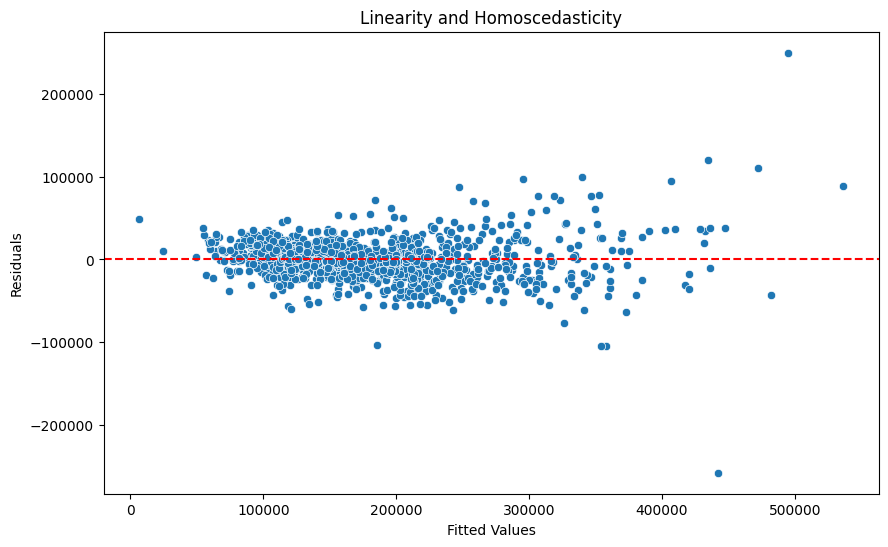

In [14]:
plot_homoscedasticity(ols_residuals, ols_fitted_values)

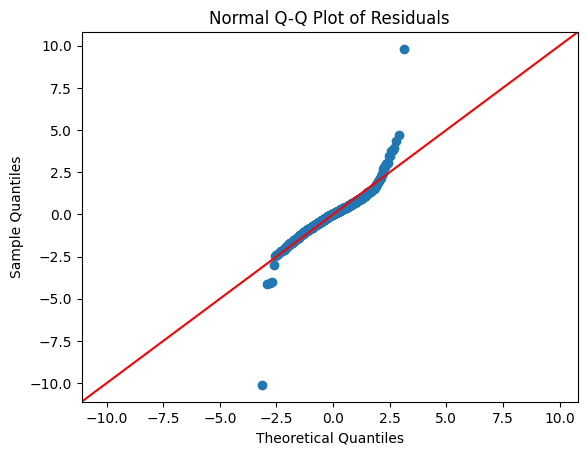

In [15]:
plot_qq(ols_residuals)  # light-tailed

In [16]:
skmetrics.mean_squared_error(
    test_df[dependent_var], ols_results.predict(test_df.drop(dependent_var, axis=1))
)

1150814991.5018182

In [17]:
skmetrics.mean_absolute_error(
    test_df[dependent_var], ols_results.predict(test_df.drop(dependent_var, axis=1))
)

20312.57290695764

### Robust Linear Models

In [18]:
rlm_results = sm.RLM(
    train_df[dependent_var], train_df.drop(dependent_var, axis=1)
).fit()

In [19]:
rlm_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:              SalePrice   No. Observations:                 1168
Model:                            RLM   Df Residuals:                     1053
Method:                          IRLS   Df Model:                          114
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 08 Mar 2026                                         
Time:                        20:03:04                                         
No. Iterations:                    10                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1.797e+05    623.371    288.333      0.000    1.79e+05    1.81e+05
ExterQual_TA             6.498e+11    1.7e+16   3.83e-05      1.000   -3.32e+16    3.32e+16
LandContour_HLS          5.653e+16   2.16e+16      2.617      0.009    1.42e+16    9.89e+16
BsmtFinType1_Unf         7.429e+15   2.77e+16      0.268      0.789   -4.69e+16    6.18e+16
TotRmsAbvGrd            -1.943e+04   4739.936     -4.100      0.000   -2.87e+04   -1.01e+04
YearRemodAdd            -4.442e+05   2.47e+05     -1.799      0.072   -9.28e+05    3.97e+04
CentralAir_Y             1.018e+16   3.45e+16      0.295      0.768   -5.73e+16    7.77e+16
GarageFinish_RFn        -6.208e+15   1.41e+16     -0.441      0.659   -3.38e+16    2.14e+16
BsmtUnfSF               -3943.4902   2168.665     -1.818      0.069   -8193.995     307.014
Neighborhood_StoneBr     3.403e+15   3.22e+16      0.106      0.916   -5.97e+16    6.65e+16
1stFlrSF                 2.509e+04   3431.775      7.310      0.000    1.84e+04    3.18e+04
BsmtFinType1_Rec        -2.287e+16   3.82e+16     -0.599      0.549   -9.77e+16     5.2e+16
ExterQual_Fa             1.608e+15   1.88e+15      0.853      0.393   -2.09e+15     5.3e+15
SaleType_WD             -3.584e+16   8.59e+15     -4.171      0.000   -5.27e+16    -1.9e+16
Neighborhood_MeadowV     7.425e+15   9.11e+15      0.815      0.415   -1.04e+16    2.53e+16
Neighborhood_Sawyer     -6.884e+14   2.62e+16     -0.026      0.979   -5.19e+16    5.06e+16
ExterCond_TA             8.829e+15   1.44e+16      0.611      0.541   -1.95e+16    3.71e+16
HalfBath                 1.012e+04   2281.552      4.437      0.000    5651.469    1.46e+04
Neighborhood_BrDale     -1.304e+16   8.86e+15     -1.471      0.141   -3.04e+16    4.33e+15
ScreenPorch              -886.6696   1715.063     -0.517      0.605   -4248.131    2474.792
SaleCondition_Normal    -1.092e+16   1.05e+16     -1.037      0.300   -3.16e+16    9.73e+15
PavedDrive_Y             1.295e+16   2.08e+16      0.623      0.533   -2.78e+16    5.37e+16
MasVnrArea              -1276.2288   1411.522     -0.904      0.366   -4042.761    1490.304
GarageArea              -6332.2162   2460.340     -2.574      0.010   -1.12e+04   -1510.039
Neighborhood_NridgHt     1.917e+16   8.16e+15      2.348      0.019    3.17e+15    3.52e+16
Fireplaces               1110.9593   1672.705      0.664      0.507   -2167.482    4389.401
Foundation_CBlock        1.663e+15   1.88e+16      0.088      0.930   -3.52e+16    3.85e+16
Neighborhood_IDOTRR      2.041e+15   2.76e+15      0.740      0.459   -3.36e+15    7.45e+15
Neighborhood_NoRidge    -2.966e+16   2.48e+16     -1.198      0.231   -7.82e+16    1.89e+16
SaleType_New            -3.978e+16   1.03e+16     -3.860      0.000      -6e+16   -1.96e+16
Electrical_FuseF         6.477e+15   2.93e+16  

In [20]:
rlm_residuals = rlm_results.resid
rlm_fitted_values = rlm_results.fittedvalues

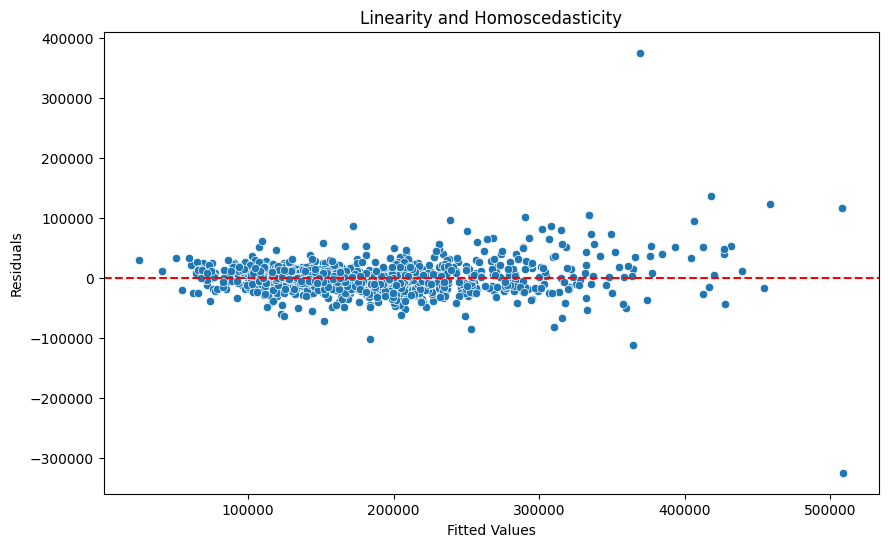

In [21]:
plot_homoscedasticity(rlm_residuals, rlm_fitted_values)

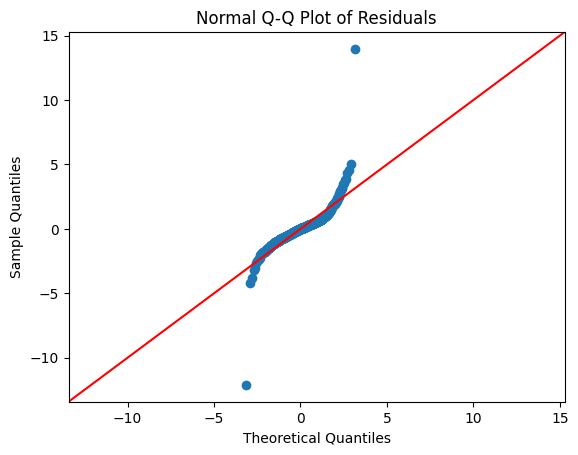

In [22]:
plot_qq(rlm_residuals)  # light-tailed

In [23]:
skmetrics.mean_squared_error(
    test_df[dependent_var], rlm_results.predict(test_df.drop(dependent_var, axis=1))
)

1259391064.8733072

In [24]:
skmetrics.mean_absolute_error(
    test_df[dependent_var], rlm_results.predict(test_df.drop(dependent_var, axis=1))
)

19551.682910054347